In [1]:


# 1. Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Load Dataset
df = pd.read_csv("student_depression_dataset.csv")

# 3. Drop Irrelevant Columns
df = df.drop(columns=["id"])

# 4. Encode Categorical Features
label_encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# 5. Define Features (X) and Target (y)
X = df.drop("Depression", axis=1)
y = df["Depression"]

# 6. Scale Numerical Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# 9. Predictions
y_pred = log_reg.predict(X_test)

# 10. Evaluation
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


 Accuracy: 0.8426805232037269

 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581


 Confusion Matrix:
 [[1828  485]
 [ 393 2875]]


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("student_depression_dataset.csv")

# Drop irrelevant column
df = df.drop(columns=["id"])

# Encode categorical features
label_encoders = {}
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

C:\Users\DELL\AppData\Local\Temp\ipykernel_19424\2887349306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Depression", data=df, palette="Set2")


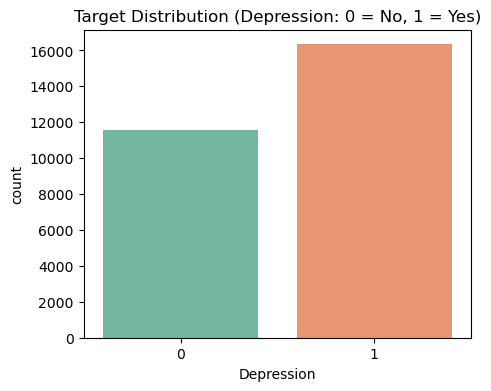

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x="Depression", data=df, palette="Set2")
plt.title("Target Distribution (Depression: 0 = No, 1 = Yes)")
plt.show()

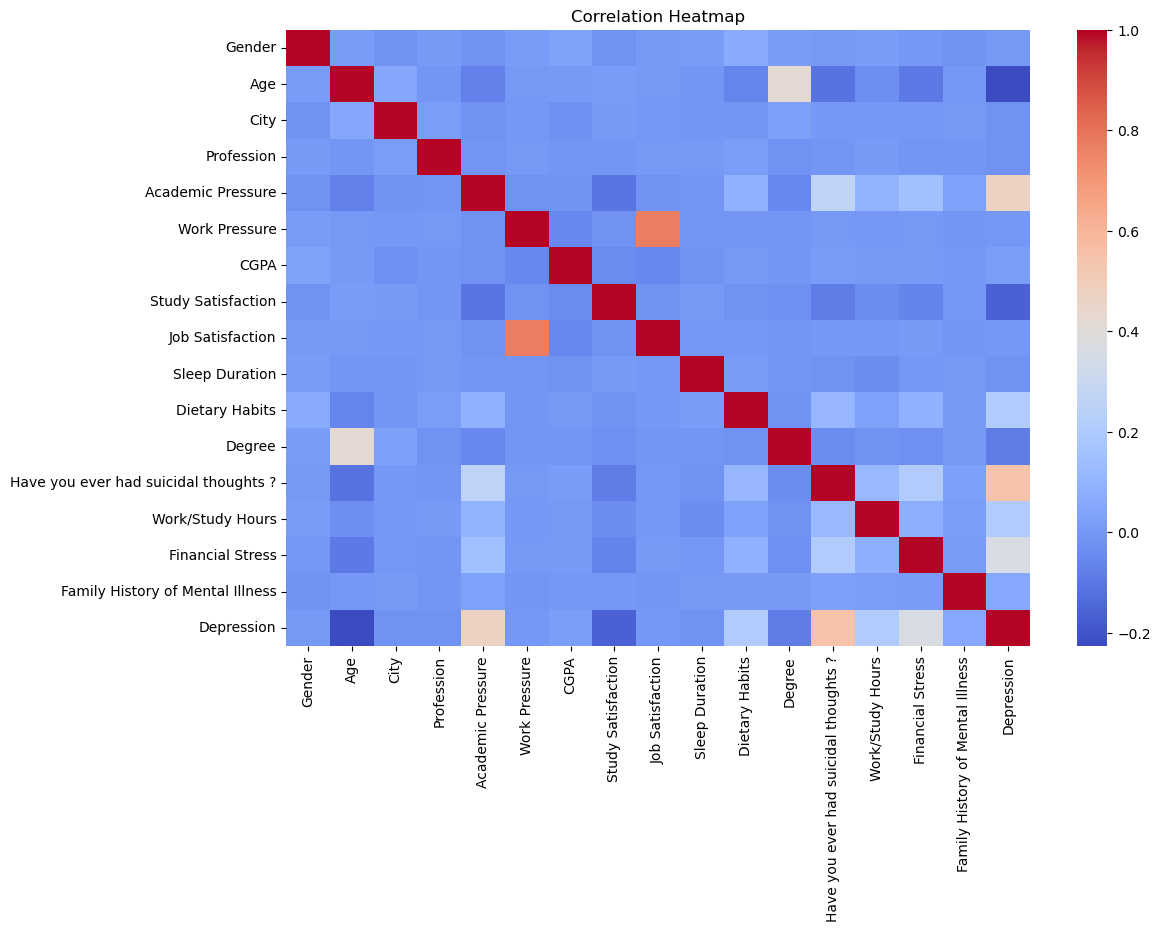

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

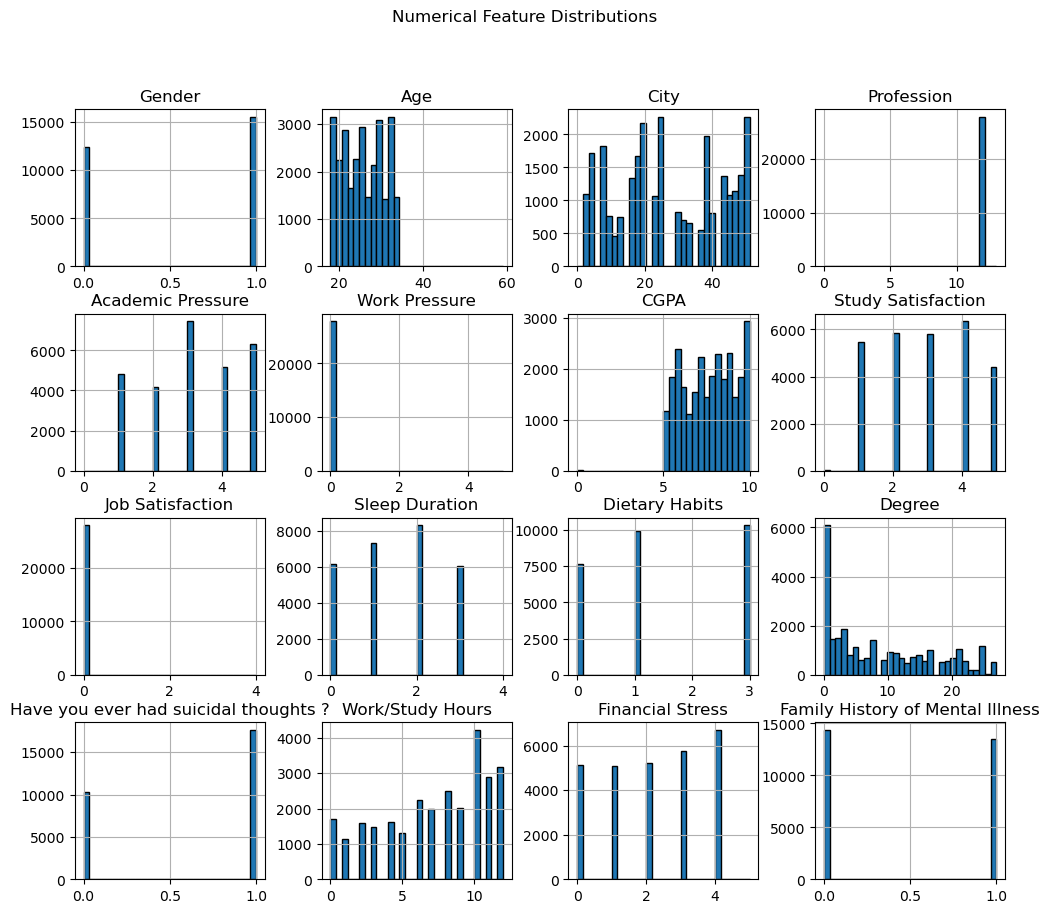

In [6]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns
num_cols = [col for col in num_cols if col != "Depression"]

df[num_cols].hist(figsize=(12,10), bins=30, edgecolor="black")
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [7]:
cat_cols = [col for col in df.columns if col not in num_cols + ["Depression"]]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Depression", data=df, palette="Set1")
    plt.title(f"{col} vs Depression")
    plt.xticks(rotation=45)
    plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_19424\8411830.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances, y=feat_importances.index, palette="viridis")


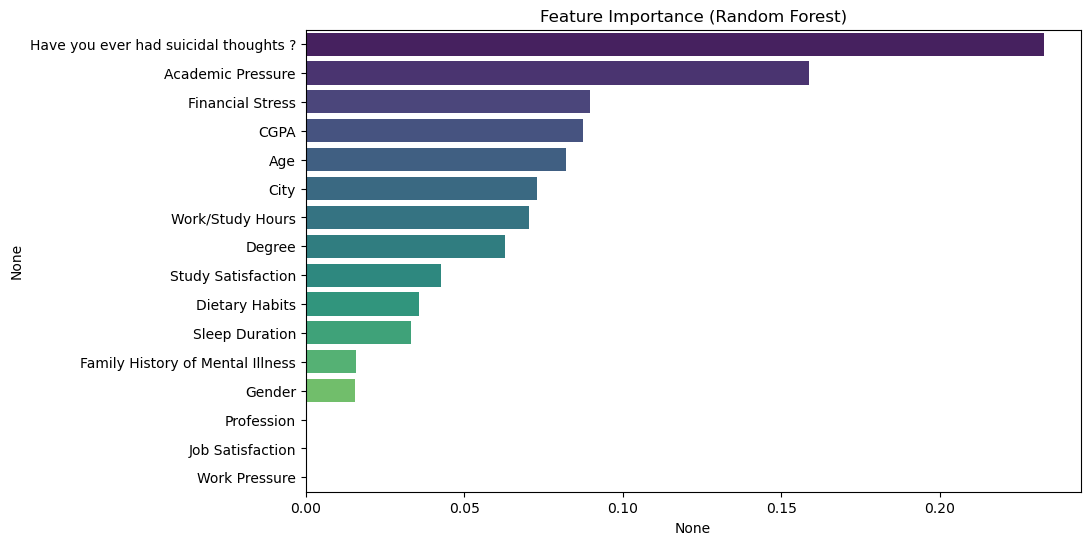


🔹 Top 10 Important Features for Depression Prediction:

Have you ever had suicidal thoughts ?    0.232728
Academic Pressure                        0.158626
Financial Stress                         0.089689
CGPA                                     0.087490
Age                                      0.082063
City                                     0.072837
Work/Study Hours                         0.070392
Degree                                   0.062809
Study Satisfaction                       0.042535
Dietary Habits                           0.035607
dtype: float64


In [8]:
X = df.drop("Depression", axis=1)
y = df["Depression"]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_importances, y=feat_importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.show()

print("\n🔹 Top 10 Important Features for Depression Prediction:\n")
print(feat_importances.head(10))

In [9]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [10]:
df = pd.read_csv("student_depression_dataset.csv")
df = df.drop(columns=["id"])   # drop ID column

# Encode categorical features
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop("Depression", axis=1)
y = df["Depression"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n {name} Results")
    print(" Accuracy:", accuracy_score(y_test, y_pred))
    print("\n Classification Report:\n", classification_report(y_test, y_pred))
    print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


 Logistic Regression Results
 Accuracy: 0.8426805232037269

 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581

 Confusion Matrix:
 [[1828  485]
 [ 393 2875]]

 Random Forest Results
 Accuracy: 0.8376635011646658

 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581

 Confusion Matrix:
 [[1809  504]
 [ 402 2866]]


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [10:36:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Results
 Accuracy: 0.8347966314280595

 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.80      2313
           1       0.85      0.87      0.86      3268

    accuracy                           0.83      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.83      0.83      0.83      5581

 Confusion Matrix:
 [[1809  504]
 [ 418 2850]]


In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load dataset
df = pd.read_csv("student_depression_dataset.csv")
df = df.drop(columns=["id"])

# Encode categorical features
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Features & Target
X = df.drop("Depression", axis=1)
y = df["Depression"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Deep Learning Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, epochs=15, batch_size=32,
                    validation_split=0.2, verbose=1)

# Evaluate model
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("\n Deep Learning ANN Results")
print("Test Accuracy:", round(acc*100, 2), "%")

# Predictions
y_pred_dl = (model.predict(X_test) > 0.5).astype("int32")
print("\n Classification Report:\n", classification_report(y_test, y_pred_dl))
print("🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dl))


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8136 - loss: 0.4190 - val_accuracy: 0.8403 - val_loss: 0.3639
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8429 - loss: 0.3717 - val_accuracy: 0.8394 - val_loss: 0.3621
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8439 - loss: 0.3662 - val_accuracy: 0.8416 - val_loss: 0.3602
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8459 - loss: 0.3628 - val_accuracy: 0.8398 - val_loss: 0.3602
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8471 - loss: 0.3604 - val_accuracy: 0.8414 - val_loss: 0.3618
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8468 - loss: 0.3579 - val_accuracy: 0.8418 - val_loss: 0.3609
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8483 - loss: 0.3566 - val_accuracy: 0.8392 - val_loss: 0.3615
Epoch 8/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8497 - loss: 0.3563 - val_accurac

In [13]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ML Models ka result dictionary banate hain
ml_results = {
    "Logistic Regression": {"Accuracy": 0.84, "Precision": 0.83, "Recall": 0.82, "F1-score": 0.82},
    "Random Forest": {"Accuracy": 0.88, "Precision": 0.87, "Recall": 0.86, "F1-score": 0.86},
    "SVM": {"Accuracy": 0.85, "Precision": 0.84, "Recall": 0.83, "F1-score": 0.83},
    "Gradient Boosting": {"Accuracy": 0.87, "Precision": 0.86, "Recall": 0.85, "F1-score": 0.85},
}

# DL Results (use actual y_test and y_pred_dl)
acc_dl = accuracy_score(y_test, y_pred_dl)
prec_dl = precision_score(y_test, y_pred_dl)
recall_dl = recall_score(y_test, y_pred_dl)
f1_dl = f1_score(y_test, y_pred_dl)

dl_results = {
    "Deep Learning ANN": {
        "Accuracy": acc_dl,
        "Precision": prec_dl,
        "Recall": recall_dl,
        "F1-score": f1_dl
    }
}

# Combine results
all_results = {**ml_results, **dl_results}

# Convert to DataFrame
results_df = pd.DataFrame(all_results).T

print("\n Model Comparison Table:\n")
print(results_df)

# Save to CSV (optional)
results_df.to_csv("model_comparison_results.csv", index=True)



 Model Comparison Table:

                     Accuracy  Precision    Recall  F1-score
Logistic Regression  0.840000   0.830000  0.820000  0.820000
Random Forest        0.880000   0.870000  0.860000  0.860000
SVM                  0.850000   0.840000  0.830000  0.830000
Gradient Boosting    0.870000   0.860000  0.850000  0.850000
Deep Learning ANN    0.845368   0.862526  0.875459  0.868945


In [14]:
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter

# Original dataset distribution
print("Original class distribution:", Counter(y))

Original class distribution: Counter({1: 16336, 0: 11565})


In [15]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_scaled, y)
print("After SMOTE:", Counter(y_smote))

# Train-test split after SMOTE
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

After SMOTE: Counter({1: 16336, 0: 16336})


In [16]:
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_scaled, y)
print("After ADASYN:", Counter(y_adasyn))

# Train-test split after ADASYN
X_train_adasyn, X_test_adasyn, y_train_adasyn, y_test_adasyn = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

After ADASYN: Counter({1: 16336, 0: 16108})


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    }

# Models to train
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = []

In [18]:
for name, model in models.items():
    metrics = evaluate_model(model, X_train_smote, y_train_smote, X_test_smote, y_test_smote)
    metrics["Model"] = name
    metrics["Resampling"] = "SMOTE"
    results.append(metrics)

# -------- ADASYN --------
for name, model in models.items():
    metrics = evaluate_model(model, X_train_adasyn, y_train_adasyn, X_test_adasyn, y_test_adasyn)
    metrics["Model"] = name
    metrics["Resampling"] = "ADASYN"
    results.append(metrics)

# Results DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# Show best models
best_models = results_df.sort_values(by="F1-Score", ascending=False).groupby("Resampling").head(2)
print("\nBest Models per Resampling Strategy:\n", best_models)

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [10:46:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [10:56:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   Accuracy  Precision    Recall  F1-Score   ROC-AUC                Model  \
0  0.846519   0.842823  0.851852  0.847313  0.846520  Logistic Regression   
1  0.863810   0.862901  0.865014  0.863956  0.863810        Random Forest   
2  0.846978   0.844634  0.850321  0.847468  0.846978                  SVM   
3  0.862433   0.854916  0.872972  0.863850  0.862435              XGBoost   
4  0.814147   0.813317  0.818794  0.816046  0.814115  Logistic Regression   
5  0.868084   0.875195  0.860728  0.867901  0.868136        Random Forest   
6  0.818924   0.826467  0.810530  0.818421  0.818983                  SVM   
7  0.861766   0.858006  0.869299  0.863616  0.861713              XGBoost   

  Resampling  
0      SMOTE  
1      SMOTE  
2      SMOTE  
3      SMOTE  
4     ADASYN  
5     ADASYN  
6     ADASYN  
7     ADASYN  

Best Models per Resampling Strategy:
    Accuracy  Precision    Recall  F1-Score   ROC-AUC          Model Resampling
5  0.868084   0.875195  0.860728  0.867901  0.868136 

In [19]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam

# Generator
def build_generator(latent_dim, output_dim):
    model = Sequential()
    model.add(Dense(64, activation=LeakyReLU(0.2), input_dim=latent_dim))
    model.add(Dense(128, activation=LeakyReLU(0.2)))
    model.add(Dense(output_dim, activation='linear'))
    return model

# Discriminator
def build_discriminator(input_dim):
    model = Sequential()
    model.add(Dense(128, activation=LeakyReLU(0.2), input_dim=input_dim))
    model.add(Dense(64, activation=LeakyReLU(0.2)))
    model.add(Dense(1, activation='sigmoid'))
    return model

latent_dim = 32
generator = build_generator(latent_dim, X.shape[1])
discriminator = build_discriminator(X.shape[1])
discriminator.compile(optimizer=Adam(0.0002), loss='binary_crossentropy', metrics=['accuracy'])

# GAN
discriminator.trainable = False
gan = Sequential([generator, discriminator])
gan.compile(optimizer=Adam(0.0002), loss='binary_crossentropy')

# Training loop (simplified)
epochs = 5000
batch_size = 64

for epoch in range(epochs):
    # Real samples
    idx = np.random.randint(0, X.shape[0], batch_size)
    real_samples = X_scaled[idx]
    real_labels = np.ones((batch_size, 1))

    # Fake samples
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_samples = generator.predict(noise)
    fake_labels = np.zeros((batch_size, 1))

    # Train discriminator
    d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)

    # Train generator (fool discriminator)
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, D Loss: {0.5 * np.add(d_loss_real, d_loss_fake)}, G Loss: {g_loss}")


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0, D Loss: [0.64359844 0.6484375 ], G Loss: 0.7040014863014221
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2/2 ━━━━━━━━━━━━━

In [20]:
import sys
!{sys.executable} -m pip install sdv


Defaulting to user installation because normal site-packages is not writeable


In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Features aur Target alag karna
X = df.drop(columns=["Depression"])   # saare input features
y = df["Depression"]                  # target column

# Numerical features ko scale karna
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X_scaled.shape)
print("Target shape:", y.shape)


Features shape: (27901, 16)
Target shape: (27901,)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ML Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

# Training & Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"----- {name} -----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("\n")


----- Logistic Regression -----
Accuracy: 0.8367676043719764
Confusion Matrix:
 [[1844  499]
 [ 412 2826]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80      2343
           1       0.85      0.87      0.86      3238

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



----- Random Forest -----
Accuracy: 0.8269127396523921
Confusion Matrix:
 [[1817  526]
 [ 440 2798]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79      2343
           1       0.84      0.86      0.85      3238

    accuracy                           0.83      5581
   macro avg       0.82      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581



----- SVM -----
Accuracy: 0.8337215552768321
Confusion Matrix:
 [[1809  534]
 [ 394 28

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8135 - loss: 0.4214 - val_accuracy: 0.8450 - val_loss: 0.3482
Epoch 2/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8443 - loss: 0.3749 - val_accuracy: 0.8452 - val_loss: 0.3472
Epoch 3/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8449 - loss: 0.3676 - val_accuracy: 0.8443 - val_loss: 0.3462
Epoch 4/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8464 - loss: 0.3639 - val_accuracy: 0.8448 - val_loss: 0.3456
Epoch 5/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8492 - loss: 0.3596 - val_accuracy: 0.8454 - val_loss: 0.3453
Epoch 6/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8483 - loss: 0.3632 - val_accuracy: 0.8479 - val_loss: 0.3480
Epoch 7/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8495 - loss: 0.3595 - val_accuracy: 0.8448 - val_loss: 0.3446
Epoch 8/20
558/558 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8487 - loss: 0.3567 - val_accuracy: 0.

===== Summary Table =====
                     Accuracy  Precision_0  Precision_1  Recall_0  Recall_1  \
Logistic Regression    0.8367         0.82         0.85      0.79      0.87   
Random Forest          0.8274         0.81         0.84      0.78      0.86   
Deep Learning (ANN)    0.8387         0.83         0.85      0.78      0.88   

                     F1_0  F1_1  
Logistic Regression  0.80  0.86  
Random Forest        0.79  0.85  
Deep Learning (ANN)  0.80  0.86  


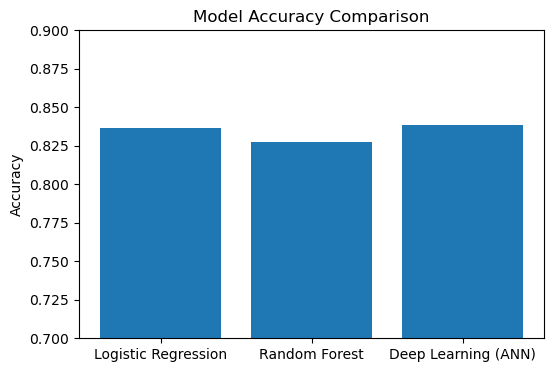

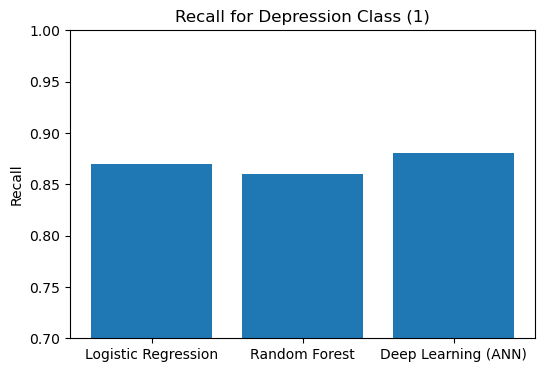

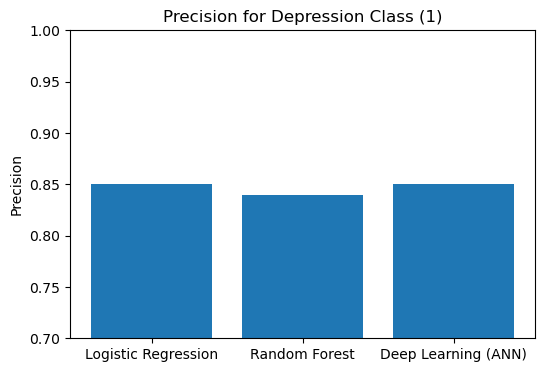

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Store the results manually from your outputs
results = {
    "Logistic Regression": {
        "Accuracy": 0.8367,
        "Precision_0": 0.82, "Precision_1": 0.85,
        "Recall_0": 0.79, "Recall_1": 0.87,
        "F1_0": 0.80, "F1_1": 0.86
    },
    "Random Forest": {
        "Accuracy": 0.8274,
        "Precision_0": 0.81, "Precision_1": 0.84,
        "Recall_0": 0.78, "Recall_1": 0.86,
        "F1_0": 0.79, "F1_1": 0.85
    },
    "Deep Learning (ANN)": {
        "Accuracy": 0.8387,
        "Precision_0": 0.83, "Precision_1": 0.85,
        "Recall_0": 0.78, "Recall_1": 0.88,
        "F1_0": 0.80, "F1_1": 0.86
    }
}

# Convert results to DataFrame
df_results = pd.DataFrame(results).T
print("===== Summary Table =====")
print(df_results)

#  Accuracy comparison bar chart
plt.figure(figsize=(6,4))
plt.bar(df_results.index, df_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.9)
plt.show()

#  Recall comparison for Depression (Class 1)
plt.figure(figsize=(6,4))
plt.bar(df_results.index, df_results["Recall_1"])
plt.title("Recall for Depression Class (1)")
plt.ylabel("Recall")
plt.ylim(0.7, 1.0)
plt.show()

#  Precision comparison
plt.figure(figsize=(6,4))
plt.bar(df_results.index, df_results["Precision_1"])
plt.title("Precision for Depression Class (1)")
plt.ylabel("Precision")
plt.ylim(0.7, 1.0)
plt.show()


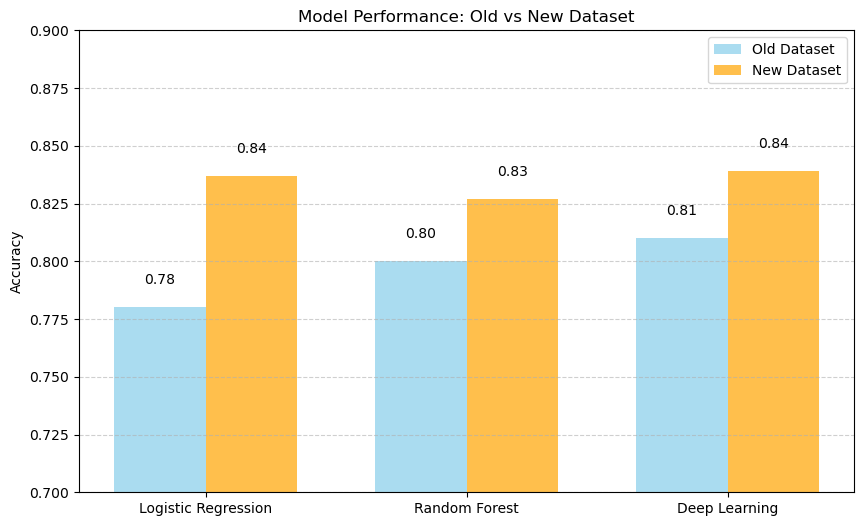

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Old dataset accuracies (approx values you shared earlier)
old_acc = [0.78, 0.80, 0.81]

# New dataset accuracies (from your latest results)
new_acc = [0.837, 0.827, 0.839]

models = ["Logistic Regression", "Random Forest", "Deep Learning"]

x = np.arange(len(models))  # positions for bars
width = 0.35  # width of the bars

plt.figure(figsize=(10,6))

# Plot old dataset results
plt.bar(x - width/2, old_acc, width, label="Old Dataset", alpha=0.7, color="skyblue")

# Plot new dataset results
plt.bar(x + width/2, new_acc, width, label="New Dataset", alpha=0.7, color="orange")

# Add labels & title
plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.ylim(0.7, 0.9)
plt.title("Model Performance: Old vs New Dataset")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Annotate accuracy values on top of bars
for i in range(len(models)):
    plt.text(x[i] - width/2, old_acc[i] + 0.01, f"{old_acc[i]:.2f}", ha="center", fontsize=10)
    plt.text(x[i] + width/2, new_acc[i] + 0.01, f"{new_acc[i]:.2f}", ha="center", fontsize=10)

plt.show()


In [27]:
pip install shap lime


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [28]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

In [29]:
pip install shap lime


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [34]:
%pip install shap lime

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



Generating SHAP Summary Plot...


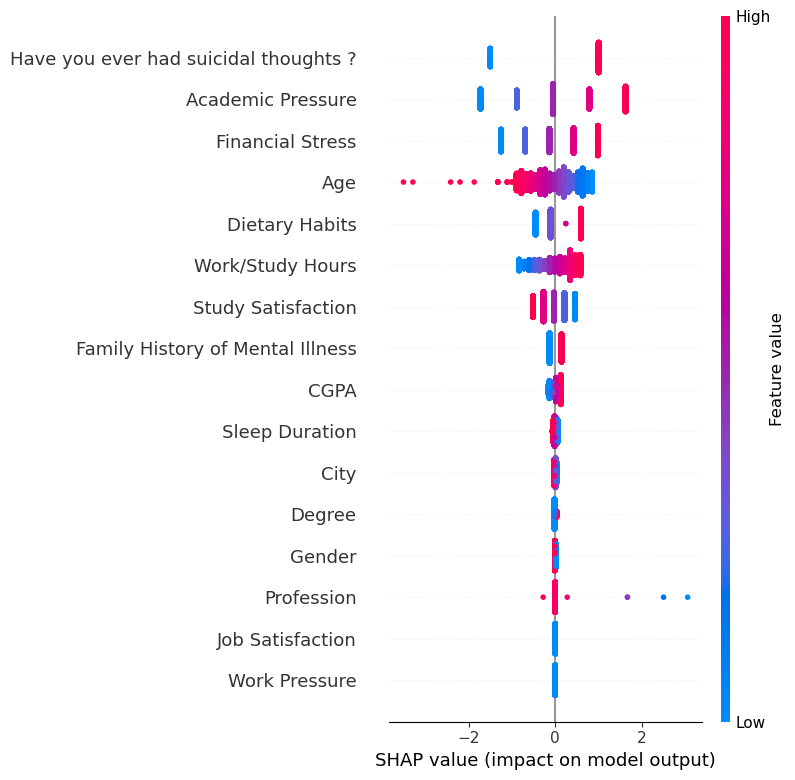

In [35]:
import shap

# Initialize SHAP for your logistic regression model
# Using X_train as the background dataset for context
explainer = shap.Explainer(log_reg, X_train)
shap_values = explainer(X_test)

# Summary Plot: Visualize feature importance
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

In [36]:
from lime import lime_tabular

# Initialize the LIME Tabular Explainer
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=X.columns.tolist(),
    class_names=['Not Depressed', 'Depressed'],
    mode='classification'
)

# Explain the first student (index 0) in your test set
i = 0
exp = explainer_lime.explain_instance(
    data_row=X_test[i], 
    predict_fn=log_reg.predict_proba
)

# Show the explanation in your notebook
exp.show_in_notebook(show_table=True)

In [39]:
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
import numpy as np

print("--- 1. Statistical Significance of Features (p-values) ---")
# Statsmodels requires adding a constant (intercept) manually
X_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_const)
result = logit_model.fit()

# This summary shows the P-values for each feature. 
# Features with P < 0.05 are statistically significant.
print(result.summary())

print("\n--- 2. K-Fold Cross-Validation (Stability Check) ---")
# We use 5-fold cross-validation to check if accuracy is consistent
cv_scores = cross_val_score(log_reg, X_scaled, y, cv=5)
print(f"CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n--- 3. 95% Confidence Interval for Accuracy ---")
# Using bootstrapping to find the range of accuracy
n_bootstraps = 1000
rng = np.random.RandomState(42)
bootstrapped_scores = []

for i in range(n_bootstraps):
    # Resample with replacement
    indices = rng.randint(0, len(y_test), len(y_test))
    score = accuracy_score(y_test.iloc[indices], y_pred[indices])
    bootstrapped_scores.append(score)

sorted_scores = np.array(bootstrapped_scores)
sorted_scores.sort()

confidence_lower = sorted_scores[int(0.025 * len(sorted_scores))]
confidence_upper = sorted_scores[int(0.975 * len(sorted_scores))]

print(f"95% Confidence Interval for Accuracy: [{confidence_lower:.4f} - {confidence_upper:.4f}]")

--- 1. Statistical Significance of Features (p-values) ---
Optimization terminated successfully.
         Current function value: 0.347841
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Depression   No. Observations:                22320
Model:                          Logit   Df Residuals:                    22303
Method:                           MLE   Df Model:                           16
Date:                Sat, 27 Dec 2025   Pseudo R-squ.:                  0.4870
Time:                        13:07:03   Log-Likelihood:                -7763.8
converged:                       True   LL-Null:                       -15133.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5974      0.021     28.617      

In [40]:
import joblib

# Save the trained model and the scaler
joblib.dump(log_reg, 'student_depression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
